# 01 · Data Exploration

Walk through the two data sources Gaffer consumes: the bundled historical CSV (8 seasons, ~300k rows) and the live FPL API bootstrap. The goal is a quick shape check — what columns exist, how they distribute, and where the joins happen.

In [4]:
from gaffer.providers.historical_csv import HistoricalCsvProvider
from gaffer.providers.fpl_api import LiveFplApiProvider

hist = HistoricalCsvProvider().get_historical_gwdata()
print(hist.shape, hist['season'].unique())
hist.head()

(196538, 35) <ArrowStringArray>
['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23',
 '2023-24']
Length: 8, dtype: str


,name,assists,bonus,bps,clean_sheets,creativity,goals_conceded,goals_scored,ict_index,influence,...,was_home,yellow_cards,season,position,team,opponent_team,kickoff_date,opponent_team_fdr,team_fdr,nb_managers
0,Aaron Cresswell,0,0,0,0,0.0,0,0,0.0,0.0,...,False,0,2016-17,DEF,West Ham,Chelsea,2016-08-15,4.0,3.0,4500000.0
1,Aaron Lennon,0,0,6,0,0.3,0,0,0.9,8.2,...,True,0,2016-17,MID,Everton,Spurs,2016-08-13,4.0,3.0,4500000.0
2,Aaron Ramsey,0,0,5,0,4.9,3,0,3.0,2.2,...,True,0,2016-17,MID,Arsenal,Liverpool,2016-08-14,5.0,4.0,4500000.0
3,Abdoulaye Doucouré,0,0,0,0,0.0,0,0,0.0,0.0,...,False,0,2016-17,MID,Watford,Southampton,2016-08-13,2.0,3.0,4500000.0
4,Abdul Rahman Baba,0,0,0,0,0.0,0,0,0.0,0.0,...,True,0,2016-17,DEF,Chelsea,West Ham,2016-08-15,3.0,4.0,4500000.0


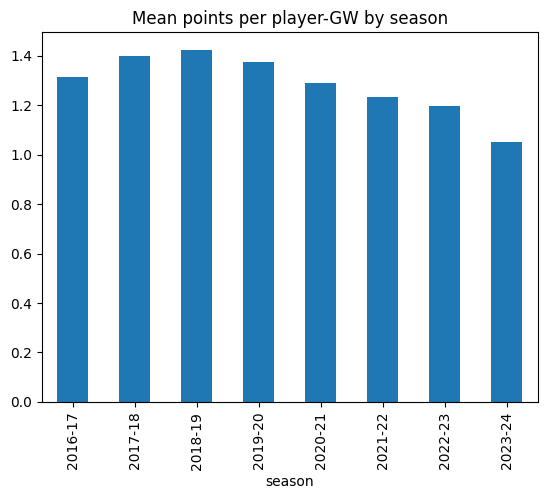

In [5]:
import matplotlib.pyplot as plt

hist.groupby('season')['total_points'].mean().plot.bar()
plt.title('Mean points per player-GW by season')
plt.show()

In [6]:
fpl = LiveFplApiProvider()
bootstrap = fpl.get_bootstrap()
print(f"{len(bootstrap.id_to_player_name)} players, {len(bootstrap.id_to_team_name)} teams")
bootstrap.elements_df[['id', 'first_name', 'second_name', 'now_cost', 'total_points']].head()

829 players, 20 teams


,id,first_name,second_name,now_cost,total_points
0,1,David,Raya Martín,60,131
1,2,Kepa,Arrizabalaga Revuelta,40,0
2,3,Karl,Hein,40,0
3,4,Tommy,Setford,39,0
4,5,Gabriel,dos Santos Magalhães,71,177


**Next:** `02_feature_engineering.ipynb` — turn these raw frames into model inputs.